# Performance Analysis

This notebook analyzes model performances on each benchmark's capability tree nodes. We'll perform the following analyses:

- Compute each model's win rate

## Set Up

Import modules.

In [1]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from pathlib import Path
from tqdm import tqdm
from utils.path import (
    resolve_datasets_dir,
    resolve_eval_results_dir,
    resolve_results_dir,
    resolve_plots_dir,
)

## Preprocessing

Identify all available datasets.

In [2]:
datasets_dir = resolve_datasets_dir()
all_datasets = [d.name for d in datasets_dir.iterdir() if d.is_dir()]

print(f"Found {len(all_datasets)} available datasets:")
for i, dataset in enumerate(all_datasets):
    print(f"{i + 1}: {dataset}")

Found 7 available datasets:
1: Chatbot-Arena
2: CollegeMath
3: DS-1000
4: MATH
5: MMLU
6: ShareGPT10K
7: WildChat10K


Only keep datasets that have evaluation results for multiple real models.

In [3]:
datasets, removed_datasets = [], []

for dataset in sorted(all_datasets):
    results_dir = resolve_eval_results_dir(dataset)
    num_results = len(list(results_dir.iterdir()))
    print(f"{dataset}: {num_results} models")

    if num_results > 1:
        datasets.append(dataset)
    else:
        removed_datasets.append(dataset)

print(f"{'-' * 100}\nDatasets with multiple real models: {datasets}")
print(f"Removed datasets: {removed_datasets}")

Chatbot-Arena: 1 models
CollegeMath: 3 models
DS-1000: 3 models
MATH: 3 models
MMLU: 3 models
ShareGPT10K: 1 models
WildChat10K: 1 models
----------------------------------------------------------------------------------------------------
Datasets with multiple real models: ['CollegeMath', 'DS-1000', 'MATH', 'MMLU']
Removed datasets: ['Chatbot-Arena', 'ShareGPT10K', 'WildChat10K']


For each remaining dataset, create a DataFrame containing each model's per-instance performance and save the it to a CSV file. The rows will be different instances and the columns will be different models.

In [4]:
dataset_to_df = {}

for dataset in datasets:
    csv_path = resolve_results_dir() / f"{dataset}.csv"
    if csv_path.exists():
        print(f"Skipping {dataset} because it already exists")
        dataset_to_df[dataset] = pd.read_csv(csv_path)
        continue

    models_dir = resolve_eval_results_dir(dataset)

    data = {}
    for model in models_dir.iterdir():
        results_file = model / "results.json"
        if not model.is_dir() or not results_file.exists():
            continue

        with open(results_file) as f:
            data[model.name] = json.load(f)

    df = pd.DataFrame(data)
    print(f"{dataset}: {len(df)} instances")
    display(df.head())

    df.to_csv(csv_path, index=False)
    print(f"Saved {dataset}'s performance matrix to {csv_path}\n{'-' * 100}")
    dataset_to_df[dataset] = df

Skipping CollegeMath because it already exists
Skipping DS-1000 because it already exists
Skipping MATH because it already exists
Skipping MMLU because it already exists


View each DataFrame.

In [5]:
for dataset, df in dataset_to_df.items():
    print(f"{dataset}: {len(df)} instances")
    display(df.head())

CollegeMath: 2818 instances


,dart-math-llama3-8b-uniform,gpt-4o-mini-2024-07-18,Llama-3.1-8B-Instruct
0,1,1,1
1,1,1,0
2,0,1,1
3,1,1,1
4,0,1,1


DS-1000: 1000 instances


,deepseek-coder-6.7b-base,gpt-3.5-turbo-0613,gpt-4o-2024-08-06
0,1,0,0
1,0,1,1
2,1,0,1
3,1,1,1
4,0,1,0


MATH: 5000 instances


,dart-math-llama3-8b-uniform,gpt-4o-mini-2024-07-18,Llama-3.1-8B-Instruct
0,1,1,1
1,1,1,1
2,0,1,0
3,1,1,1
4,1,1,1


MMLU: 14042 instances


,gpt-4o-mini-2024-07-18,Llama-3.1-8B-Instruct,Llama-3.1-Tulu-3-8B
0,1,1,1
1,0,1,0
2,0,1,0
3,0,0,0
4,1,1,1


## Win Rate Analysis

For each dataset, compute each model's mean accuracy across all instances.

Saved plot to C:\Users\Mike\vscode\EvalTree\Plots\mean_accuracies.png


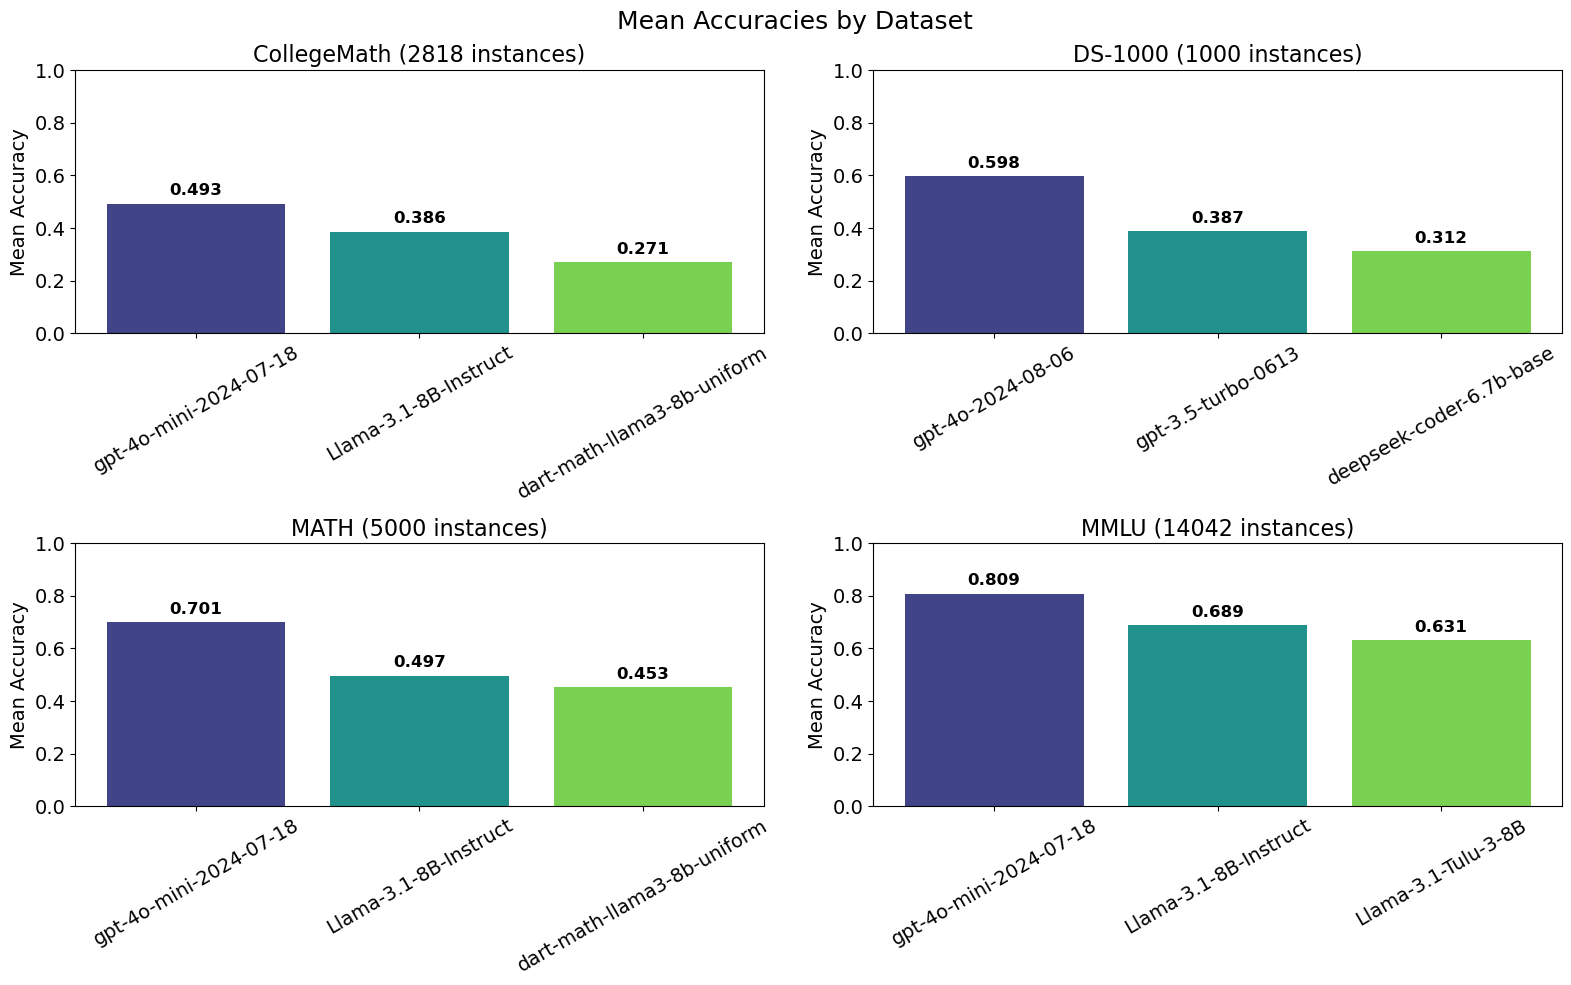

In [10]:
nrows = len(datasets) // 2
ncols = nrows
figsize = (16, 10)
label_rotation = 30
label_fontsize = 14
title_fontsize = 16
annotation_fontsize = 12
suptitle_fontsize = 18

fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
axes = axes.flatten()

for idx, (dataset, df) in enumerate(dataset_to_df.items()):
    ax = axes[idx]
    mean_accuracies = df.mean(axis=0).sort_values(ascending=False)

    # Plot mean accuracies
    bars = ax.bar(
        range(len(mean_accuracies)),
        mean_accuracies.values,
        color=plt.cm.viridis(np.linspace(0.2, 0.8, len(mean_accuracies))),
    )

    # Styling
    ax.set_xticks(range(len(mean_accuracies)))
    ax.tick_params(axis="both", labelsize=label_fontsize)
    ax.set_xticklabels(mean_accuracies.index, rotation=label_rotation)
    ax.set_ylabel("Mean Accuracy", fontsize=label_fontsize)
    ax.set_title(f"{dataset} ({len(df)} instances)", fontsize=title_fontsize)
    ax.set_ylim(0, 1)

    # Add value labels on bars
    for bar, val in zip(bars, mean_accuracies.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=annotation_fontsize,
            fontweight="bold",
        )

plt.suptitle("Mean Accuracies by Dataset", fontsize=suptitle_fontsize)
plt.tight_layout()
out_path = resolve_plots_dir() / "mean_accuracies.png"
plt.savefig(out_path)
print(f"Saved plot to {out_path}")
plt.show()

**Observations**
- CollegeMath:
  - There's a clear global ranking, but the performance gap of ~10 accuracy points between each model doesn't seem too large
- DS-1000:
  - GPT-3.5-Turbo seems better than DeepSeek-Coder by ~6 accuracy points
  - However, GPT-4o-mini beats both of them ~20-30 accuracy points
- MATH:
  - Llama-3.1-8B-Instruct and DART-Math-Llama only differ by ~4 accuracy points
  - However, GPT-4o-mini beats both of them by ~20-25 accuracy points
- MMLU:
  - Llama-3.1-8B-Instruct and Llama-3.1-Tulu-8B only differ by ~6 accuracy points
  - However,  GPT-4o-mini beats both of them by ~10-15 accuracy points

**Analysis**
- Across all benchmarks, GPT-4o-mini is consistently the best model across all instances by ~10-30 accuracy points
- GPT-4o-mini's competitors typically have similar overall performances to each other, differing by ~5-10 accuracy points

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kendalltau

num_splits = 500
sample_size_per_half = 50  # Use smaller samples to see ranking variance

for dataset in datasets:
    in_path = results_dir / f"{dataset}.csv"
    df = pd.read_csv(in_path)

    num_instances, num_models = df.shape
    half_size = min(sample_size_per_half, num_instances // 2)

    # --- Debug info ---
    print(f"\n{dataset}: {num_instances} instances, {num_models} models")
    print(
        f"Split size: {half_size} instances per half (using smaller samples to see variance)"
    )

    # --- Split-half: compute tau between each half's rankings ---
    taus = np.empty(num_splits, dtype=np.float64)

    kwargs = {
        "desc": f"Split-half {dataset}",
        "total": num_splits,
        "unit": "split",
    }

    for i in tqdm(range(num_splits), **kwargs):
        # Shuffle and split into two halves
        shuffled = df.sample(frac=1)
        half1 = shuffled.iloc[:half_size]
        half2 = shuffled.iloc[half_size : 2 * half_size]

        # Compute rankings for each half
        scores1 = half1.mean(axis=0).to_numpy()
        scores2 = half2.mean(axis=0).to_numpy()

        order1 = np.argsort(-scores1, kind="stable")
        order2 = np.argsort(-scores2, kind="stable")

        ranks1 = np.empty(num_models, dtype=np.int32)
        ranks2 = np.empty(num_models, dtype=np.int32)
        ranks1[order1] = np.arange(1, num_models + 1)
        ranks2[order2] = np.arange(1, num_models + 1)

        tau = kendalltau(ranks1, ranks2).correlation
        taus[i] = tau if tau is not None else np.nan

    # Drop any NaNs just in case
    taus = taus[~np.isnan(taus)]

    # --- Plot histogram for this dataset ---
    plt.figure()
    plt.hist(taus, bins=30)
    plt.title(f"{dataset}: Split-half Kendall's tau (N={num_splits})")
    plt.xlabel("Kendall's tau")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    print(
        f"{dataset} — tau mean={taus.mean():.4f}, std={taus.std():.4f}, "
        f"min={taus.min():.4f}, max={taus.max():.4f}"
    )

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Mike\\vscode\\EvalTree\\Datasets\\WildChat10K\\eval_results\\real\\CollegeMath.csv'